In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from IPython.display import display, Markdown, Math, HTML
import matplotlib.pyplot as plt
from optomechanics_levitation import (
    particle_properties,
    input_beam_waist_from_filling_factor, electric_field_amplitude_from_power, evaluate_incident_field,
    hermite_gauss_00,
    evaluate_internal_field, evaluate_near_field, evaluate_far_field
)

In [18]:
# Define nanoparticle
ellipsoidal_particle = particle_properties(
    particle_type="spheroid", material_name="sio2", step_nm=10, mesh="hex", 
    center=True, R1=5, R2=5, R3=10
)

In [19]:
# Optical parameters
f0 = 1.0; NA = 0.75; f = 1.0 # [mm]
wavelength = 1550.0; n = 1.0
w0 = input_beam_waist_from_filling_factor(
    filling_factor=f0, numerical_aperture=NA, focal_length_mm=f, refractive_index=n)
power = 0.1 # [W]
impedance = 376.730313668 # [Ohms]
profile_power_integral = np.pi * (w0 * 1e-3)**2 / 2 # Analitical solution for a guassian profile: in [m2]
amplitude_v_per_m = electric_field_amplitude_from_power(
    power_w=power, profile_power_integral_m2=profile_power_integral, impedance_ohms=impedance
)

# Optical profile
hermitegauss_params = dict(
    positions_nm=ellipsoidal_particle["geometry_nm"],
    wavelength_nm=wavelength,
    environment={"eps1": 1.0, "eps2": 1.0, "eps3": 1.0},
    amplitude_v_per_m=amplitude_v_per_m,
    field="both",
    theta=0, NA=NA, f=f, w0=w0,
    xSpot=0, ySpot=0, zSpot=0, kSign=-1, phase=0, quadrature_points=24, N_cpu=4
)
# Generate optical field
incident_efield, incident_bfield = evaluate_incident_field(field_generator=hermite_gauss_00, **hermitegauss_params)

Electric field in each particle's dipoles positions before any interaction.

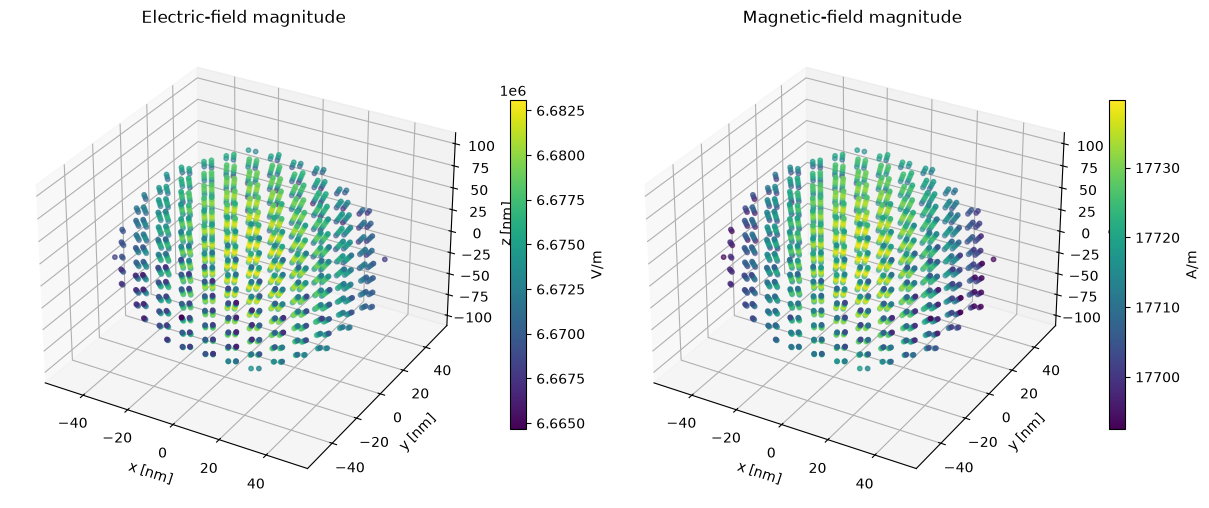

In [20]:
positions = hermitegauss_params["positions_nm"]
fig = plt.figure(figsize=(12, 5), layout="constrained")
for panel, values, title, units in [(1, incident_efield, "Electric-field magnitude", "V/m"), (2, incident_bfield, "Magnetic-field magnitude", "A/m")]:
    magnitude = np.linalg.norm(values, axis=1)
    ax = fig.add_subplot(1, 2, panel, projection="3d")
    plot = ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=magnitude, cmap="viridis", s=10)
    ax.set(xlabel="x [nm]", ylabel="y [nm]", zlabel="z [nm]", title=title)
    fig.colorbar(plot, ax=ax, label=units, shrink=0.7)
plt.show()

Only the electric field determines the induced polarization

In [21]:
particle_internal_interaction = evaluate_internal_field(
    particle=ellipsoidal_particle, incident_electric_field=incident_efield, wavelength_nm=wavelength, 
    environment=hermitegauss_params["environment"]
)

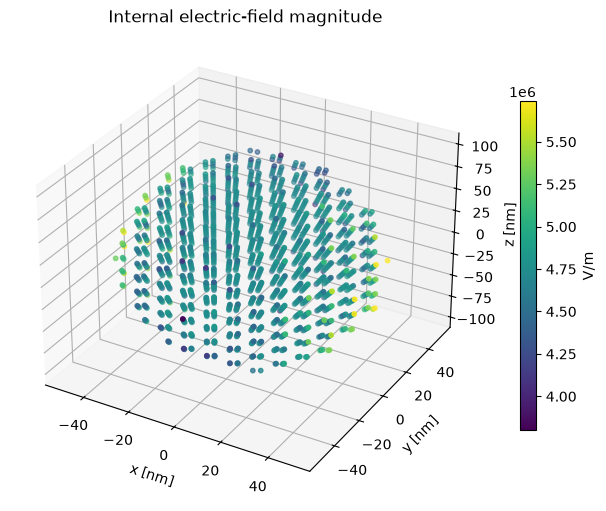

In [22]:
positions = ellipsoidal_particle["geometry_nm"]
E_internal = particle_internal_interaction["E_internal"]
magnitude = np.linalg.norm(E_internal, axis=1)

fig = plt.figure(figsize=(7, 5), layout="constrained")
ax = fig.add_subplot(111, projection="3d")
plot = ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=magnitude, cmap="viridis", s=10)
ax.set(xlabel="x [nm]", ylabel="y [nm]", zlabel="z [nm]", title="Internal electric-field magnitude")
fig.colorbar(plot, ax=ax, label="V/m", shrink=0.7)
plt.show()

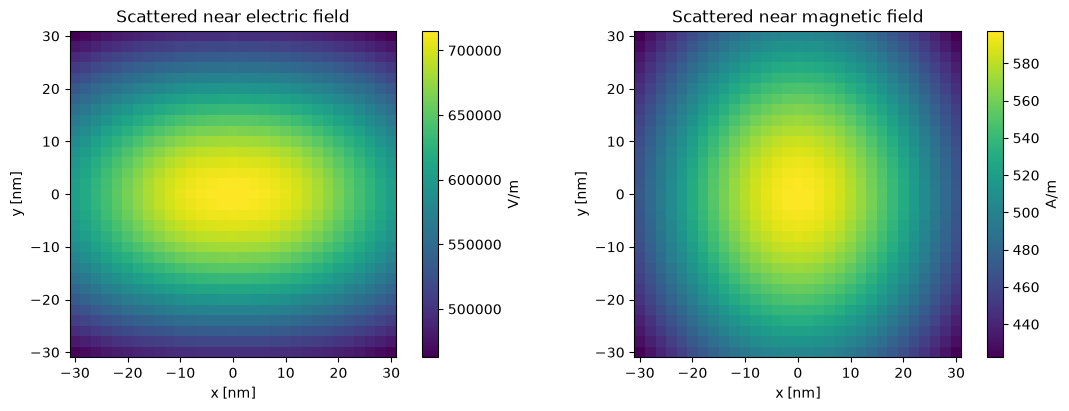

In [23]:
geometry = ellipsoidal_particle["geometry_nm"]
step = ellipsoidal_particle["step_nm"]  # 10 nm
top = geometry[np.argmax(geometry[:, 2])]

center = (geometry.min(axis=0) + geometry.max(axis=0)) / 2
x = np.linspace(center[0] - 3*step, center[0] + 3*step, 31)
y = np.linspace(center[1] - 3*step, center[1] + 3*step, 31)
X, Y = np.meshgrid(x, y)

near_positions_nm = np.column_stack((X.ravel(), Y.ravel(), np.full(X.size, top[2] + 2*step),))
# Near field calculation
near_efield, near_hfield = evaluate_near_field(particle_internal_interaction, near_positions_nm, field="both")

E_magnitude = np.linalg.norm(near_efield, axis=1).reshape(X.shape)
H_magnitude = np.linalg.norm(near_hfield, axis=1).reshape(X.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, magnitude, title, units in [
    (axes[0], E_magnitude, "Scattered near electric field", "V/m"),
    (axes[1], H_magnitude, "Scattered near magnetic field", "A/m"),
]:
    plot = ax.pcolormesh(X, Y, magnitude, shading="auto", cmap="viridis")
    ax.set(xlabel="x [nm]", ylabel="y [nm]", title=title)
    ax.set_aspect("equal")
    fig.colorbar(plot, ax=ax, label=units)
plt.show()

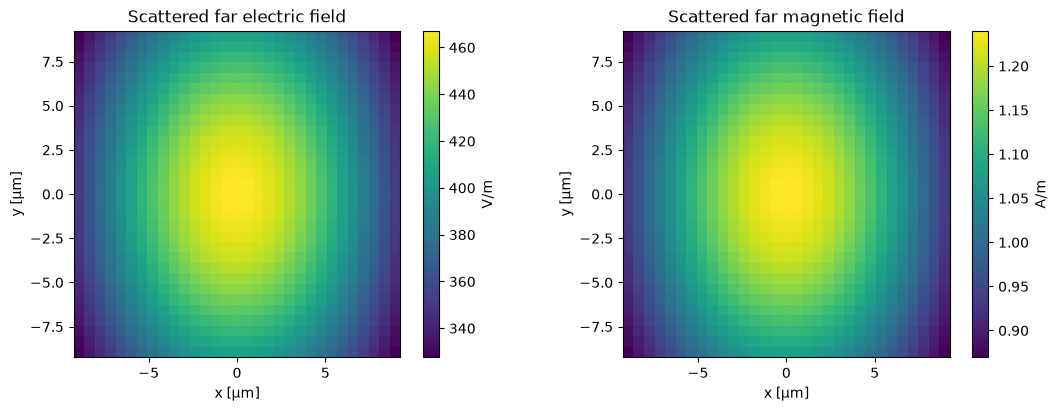

In [24]:
z_far = 10 * wavelength  # 15 500 nm
half_width = z_far * np.tan(np.deg2rad(30))

x = np.linspace(-half_width, half_width, 31)
y = np.linspace(-half_width, half_width, 31)
X, Y = np.meshgrid(x, y)

far_positions_nm = np.column_stack((X.ravel(), Y.ravel(), np.full(X.size, z_far)))
# Far field calculation
far_efield, far_hfield = evaluate_far_field(particle_internal_interaction, far_positions_nm, field="both")

E_magnitude = np.linalg.norm(far_efield, axis=1).reshape(X.shape)
H_magnitude = np.linalg.norm(far_hfield, axis=1).reshape(X.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, magnitude, title, units in [
    (axes[0], E_magnitude, "Scattered far electric field", "V/m"),
    (axes[1], H_magnitude, "Scattered far magnetic field", "A/m"),
]:
    plot = ax.pcolormesh(X / 1000, Y / 1000, magnitude, shading="auto", cmap="viridis")
    ax.set(xlabel="x [µm]", ylabel="y [µm]", title=title)
    ax.set_aspect("equal")
    fig.colorbar(plot, ax=ax, label=units)
plt.show()